## Assignment 2: BERT for SRL

`Melina Paxinou    2854344`

Link to fine-tuned model: https://drive.google.com/drive/folders/1FqjKUaX_XgTCJbfDyd7-3VZM2ZuDNVnk?usp=sharing \
Please save the contents of the zip file in the same directory as this notebook.

## Imports and paths

In [108]:
!pip install -r requirements.txt

In [3]:
from collections import Counter
from datasets import load_dataset
from evaluate import load
import pandas as pd
from datasets import Dataset
import numpy as np
from transformers import DataCollatorForTokenClassification
from transformers import set_seed
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer
import transformers
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pickle
from sklearn.preprocessing import LabelEncoder

In [4]:
train_file = "en_ewt-up-train.conllu"
dev_file = "en_ewt-up-dev.conllu"
test_file = "en_ewt-up-test.conllu"

## Duplication script for any number of predicates

In [6]:
def create_dupfile(inputfile, outputfile):
    """
    Processes a dataset with variable columns and duplicates sentences based on argument columns containing 'V'.
    Ensures only one duplication per sentence when multiple tokens share the same argument column with 'V'.
    Adds a 'chosen_predicate' column (1 for predicate, 0 otherwise).

    Parameters:
        inputfile (str): Name of the .conllu file to be preprocessed.
        outputfile (str): Name of the output tab-separated file containing the preprocessed data.

    Returns:
        None
    """
    # List of fixed columns in the dataset
    fixed_columns = ['sentence_num', 'token', 'lemma', 'uni_pos', 'penn_pos', 'morph_notes', 
                     'head', 'dep', 'enhanced_dep', 'notes', 'predicate']
    
    rows = []  # stores the rows of data read from the input file
    max_columns = 0  # tracks the maximum number of columns in any row

    # reads input file lines
    with open(inputfile, 'r', encoding='utf-8') as file:
        for line in file:
            if line.strip() and not line.startswith('#'):  # ignores empty lines and comment lines
                row = line.strip().split('\t')  # splits line into columns based on tab
                rows.append(row)  # adds row to the list
                max_columns = max(max_columns, len(row))  # updates max column count if necessary
    
    # calculates number of dynamic columns based on max number of columns in a row
    num_fixed_columns = len(fixed_columns)
    num_dynamic_columns = max_columns - num_fixed_columns
    dynamic_columns = [f'args{i + 1}' for i in range(num_dynamic_columns)]  # generates dynamic column names
    column_names = ['token_num'] + fixed_columns[1:] + dynamic_columns  # final column names for the df
    
    # creates a df from the rows with the column names
    df = pd.DataFrame(rows, columns=column_names).fillna('_')
    
    # splits the data into sentences (one sentence per list of rows)
    sentences = []
    current_sentence = []
    for _, row in df.iterrows():
        if row['token_num'] == '1' and current_sentence:  # new sentence starts when token_num is 1
            sentences.append(current_sentence)  # adds the previous sentence to the list
            current_sentence = []  # resets for the next sentence
        current_sentence.append(row)  # adds the current row to the current sentence
    if current_sentence:
        sentences.append(current_sentence)  # adds the last sentence
    
    # prepares the columns for the output file and writes in tab-separated format
    output_columns = fixed_columns + ['args', 'chosen_predicate']

    with open(outputfile, 'w', encoding='utf-8', newline='') as newfile:
        for sentence_idx, sentence in enumerate(sentences, start=1):
            sentence_df = pd.DataFrame(sentence)  # sentence to df
            v_columns = []  # list of argument columns containing 'V'
            
            # identifying columns that contain 'V' 
            for i in range(num_dynamic_columns):
                args_col = f'args{i + 1}'
                if args_col in sentence_df.columns and 'V' in sentence_df[args_col].values:
                    v_columns.append(args_col)  
            
            if not v_columns:
                continue  # skip if no predicate found
            
            # creating duplicated sentence for each argument column with 'V'
            for pred_count, args_col in enumerate(v_columns, start=1):
                duplication = sentence_df.copy()  # copying sentence df
                duplication['sentence_num'] = f"{sentence_idx}_{pred_count}"  # updating sentence number
                duplication['args'] = sentence_df[args_col]  # adding arg column
                duplication['chosen_predicate'] = (sentence_df[args_col] == 'V').astype(int)  # marking predicate in 1 to match the input of the standalone function 
                
                duplication = duplication[output_columns]
                duplication.to_csv(newfile, sep='\t', header=False, index=False)


In [7]:
create_dupfile(train_file, 'train_dup.txt')
create_dupfile(dev_file, 'dev_dup.txt')
create_dupfile(test_file, 'test_dup.txt')

In [8]:
train_final = 'train_dup.txt'
dev_final = 'dev_dup.txt'
test_final = 'test_dup.txt'

## Statistics

### Before duplication

In [11]:
def get_file_statistics_before_dup(file):
    """
    Counts the number of tokens and sentences in a file. Skips comment and empty lines.

    Parameters:
        file (str): Path to the file.

    Returns:
        dict: A dictionary containing the number of tokens and sentences.
    """
    rows = []
    with open(file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue  # skips comment and empty lines
            rows.append(line.strip().split("\t"))

    df = pd.DataFrame(rows)

    num_sentences = (df[0] == '1').sum()  # counts occurrences of '1' 
    num_tokens = len(df)  # each row represents a token

    return {"num_sentences": num_sentences, "num_tokens": num_tokens}

train_stats_v2 = get_file_statistics_before_dup(train_file)
dev_stats_v2 = get_file_statistics_before_dup(dev_file)
test_stats_v2 = get_file_statistics_before_dup(test_file)

print(f"Train file before duplication - Sentences: {train_stats_v2['num_sentences']}, Tokens: {train_stats_v2['num_tokens']}")
print(f"Dev file before duplication - Sentences: {dev_stats_v2['num_sentences']}, Tokens: {dev_stats_v2['num_tokens']}")
print(f"Test file before duplication - Sentences: {test_stats_v2['num_sentences']}, Tokens: {test_stats_v2['num_tokens']}")


Train file before duplication - Sentences: 12543, Tokens: 204609
Dev file before duplication - Sentences: 2002, Tokens: 25150
Test file before duplication - Sentences: 2077, Tokens: 25097


### After duplication

In [13]:
def get_file_statistics_after_dup(file):
    """
    Counts the number of tokens and sentences in a file.

    Parameters:
        file (str): Path to the file.

    Returns:
        dict: A dictionary containing the number of tokens and sentences.
    """
    df = pd.read_csv(file, sep='\t', names=[
        'sentence_num', 'token', 'lemma', 'uni_pos', 'penn_pos', 
        'morph_notes', 'head', 'dep', 'enhanced_dep', 'notes', 'predicate', 'args', 'chosen_predicate'
    ], dtype=str)

    num_sentences = df['sentence_num'].nunique()  # counts unique sentence IDs
    num_tokens = len(df)  # each row represents a token

    return {"num_sentences": num_sentences, "num_tokens": num_tokens}

train_stats = get_file_statistics_after_dup(train_final)
dev_stats = get_file_statistics_after_dup(dev_final)
test_stats = get_file_statistics_after_dup(test_final)

print(f"Train file after duplication - Sentences: {train_stats['num_sentences']}, Tokens: {train_stats['num_tokens']}")
print(f"Dev file after duplication - Sentences: {dev_stats['num_sentences']}, Tokens: {dev_stats['num_tokens']}")
print(f"Test file after duplication - Sentences: {test_stats['num_sentences']}, Tokens: {test_stats['num_tokens']}")


Train file after duplication - Sentences: 40482, Tokens: 1028264
Dev file after duplication - Sentences: 4977, Tokens: 105070
Test file after duplication - Sentences: 4799, Tokens: 101152


## Loading the dataset

In [15]:
# defining task, model, and batch size
task = "SRL"
model_checkpoint = "distilbert-base-uncased"
batch_size = 16

To ensure that the datasets are in a form which can be read by the model, a number of steps need to be taken. First, we created dataframes for each set (train, dev, test).



In [17]:
# creating dataframes for train, dev, and test files

# defining column names for easier access to elements
column_names = [
    'sentence_num', 'token', 'lemma', 'uni_pos', 'penn_pos',
    'morph_notes', 'head', 'dep', 'enhanced_dep', 'notes', 'predicate', 'args', 'chosen_predicate'
]

dev_df = pd.read_csv(
        dev_final,
        sep="\t",
        names=column_names,
        encoding="utf-8",
        na_filter=False, # handles empty strings and makes sure they remain as empty and not as NaN values
        low_memory=False
    )

train_df = pd.read_csv(
        train_final,
        sep="\t",
        names=column_names,
        encoding="utf-8",
        na_filter=False,
        low_memory=False
    )

test_df = pd.read_csv(
        test_final,
        sep="\t",
        names=column_names,
        encoding="utf-8",
        na_filter=False,
        low_memory=False
    )

In [18]:
# example of dataframe
test_df

,sentence_num,token,lemma,uni_pos,penn_pos,morph_notes,head,dep,enhanced_dep,notes,predicate,args,chosen_predicate
0,1_1,What,what,PRON,WP,PronType=Int,0,root,0:root,_,_,_,0
1,1_1,if,if,SCONJ,IN,_,4,mark,4:mark,_,_,_,0
2,1_1,Google,Google,PROPN,NNP,Number=Sing,4,nsubj,4:nsubj,_,_,ARG1,0
3,1_1,Morphed,morph,VERB,VBD,Mood=Ind|Tense=Past|VerbForm=Fin,1,advcl,1:advcl:if,_,morph.01,V,1
4,1_1,Into,into,ADP,IN,_,6,case,6:case,_,_,_,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
101147,2077_10,suggesting,suggest,VERB,VBG,VerbForm=Ger,7,conj,5:advcl:in|7:conj:and,_,suggest.01,_,0
101148,2077_10,exercises,exercise,NOUN,NNS,Number=Plur,16,obj,16:obj,_,exercise.02,ARG1,0
101149,2077_10,to,to,PART,TO,_,19,mark,19:mark,_,_,_,0
101150,2077_10,use,use,VERB,VB,VerbForm=Inf,17,acl,17:acl:to,SpaceAfter=No,use.01,V,1


## Preprocessing

In [24]:
def extract_gold_from_dataframe(df):
    """
    Extracts the gold labels for each token from the df.

    Parameters:
    df (DataFrame): input df 

    Returns:
    list of gold labels for each token, based on the 'args' column.
    """
    # groups by 'sentence_num'
    sentences = df.groupby('sentence_num', sort=False)
    targets = []
    for sentence_num, sentence in sentences:
        print(f"\rProgress:{sentence_num}", end="")
        for _, row in sentence.iterrows():
            # if 'args' column has '_' or 'V' (which means not an argument)
            if row['args'] == '_' or row['args'] == 'V':
                targets.append('O')
            else:
                targets.append(row['args'])
    return targets

In [25]:
train_targets = extract_gold_from_dataframe(train_df)
dev_targets = extract_gold_from_dataframe(dev_df)
test_targets = extract_gold_from_dataframe(test_df)

Progress:2077_100

In [26]:
def create_label_mapping(df, column='args'):
    """
    Creates a label encoding dictionary from a specified column in a df.
    Replaces '_' and 'V' with 'O' before encoding.

    Parameters:
    df (pd.DataFrame): input df.
    column (str): column to encode (default is 'args').

    Returns:
    dict: maps original labels to encoded values.
    """
    df = df.copy()  
    df[column] = df[column].replace({'_': 'O', 'V': 'O'})  
    
    unique_labels = df[column].unique()  # unique labels
    encoder = LabelEncoder()
    labels_encoded = encoder.fit_transform(unique_labels)  # encoded labels
    
    label_mapping = dict(zip(encoder.classes_, labels_encoded))

    # 'O' is always present and used for unknown labels
    if 'O' not in label_mapping:
        label_mapping['O'] = max(labels_encoded) + 1  

    return label_mapping


The next step is to convert each set into a list of dictionaries which contain the following keys: tokens, labels, predicate.

In [27]:
def convert_df(df):
    """
    Converts a DataFrame containing predicate annotations into a list of dictionaries suitable for BERT.

    Parameters:
    df : pandas.DataFrame
        Input DataFrame with the following required columns:
        - tokens
        - args
        - chosen_predicate (values of 0 and 1)

    Returns:
    list of dict
        List where each dictionary represents a sentence with the following keys:
        - tokens
        - labels
        - predicate: 1 for predicate, 0 otherwise
    """

    label_mapping = create_label_mapping(train_df, column='args')
    # print(label_mapping)
    # result list
    result = [
        {
            'tokens': group['token'].tolist(),
            'labels': [label_mapping.get(item, label_mapping['O']) for item in group['args']],  # mapping labels
            'predicate': [0 if val == 0 else 1 for val in group['chosen_predicate']]
        }
        for _, group in df.groupby('sentence_num', sort=False)
    ]
    # returning the result
    return result

In [28]:
# applying the convert_df function to all the dataframes 
dev_data = convert_df(dev_df)
train_data = convert_df(train_df)
test_data = convert_df(test_df)

In [29]:
# example of dictionary
print(test_data[0])

{'tokens': ['What', 'if', 'Google', 'Morphed', 'Into', 'GoogleOS', '?'], 'labels': [27, 27, 0, 27, 27, 17, 27], 'predicate': [0, 0, 0, 1, 0, 0, 0]}


The following special token is added to the dictionaries: [PRED]. I am using the augmentation technique from "NegBERT: A Transfer Learning Approach for Negation Detection and Scope Resolution" by adding a special token before the predicate. This function also updates the labels by adding the value '-100' in the place of the special token. It also preserves `predicates` by giving them the appropriate padding.

In [31]:
def augment_data(data):
    """
    Takes as input a list of dictionaries containing tokens, predicate, and labels. It adds a special token
    to indicate the predicate and updates the label for the inserted token. The original 
    sequence of tokens is preserved.

    Parameters:
    data (list of dict): A list of dictionaries where each dictionary contains:
    - tokens: list of strings (tokens of a sentence).
    - labels
    - predicate: 1 for predicate, 0 otherwise

    Returns:
    A list of dictionaries with:
    - Special token [PRED] added to the token list.
    - Labels updated to -100 for the inserted special token.
    - Predicate list padded to match the updated token list.
    """
        
    final =[]
    for sentence in data:
        
        # extracting necessary lists
        tokens = sentence['tokens']
        predicates = sentence['predicate']
        labels = sentence['labels']
    
        # processing tokens based on the predicate
        processed_tokens = []
        processed_labels = []
        processed_predicates = []
        for idx, (token, predicate) in enumerate(zip(tokens, predicates)):
            if predicate == 1:
                processed_labels.append(-100)
                processed_predicates.append(predicates[idx])
                processed_tokens.append("[PRED]")

            processed_tokens.append(token)
            processed_labels.append(labels[idx])
            processed_predicates.append(predicates[idx])
    
        final.append({
            'tokens':processed_tokens,
            'labels': processed_labels,
            'predicates': processed_predicates
        })
    return final

In [32]:
train_aug = augment_data(train_data)
dev_aug =augment_data(dev_data)
test_aug =augment_data(test_data)

In [33]:
#example of augmented data
print(test_aug[0])

{'tokens': ['What', 'if', 'Google', '[PRED]', 'Morphed', 'Into', 'GoogleOS', '?'], 'labels': [27, 27, 0, -100, 27, 27, 17, 27], 'predicates': [0, 0, 0, 1, 1, 0, 0, 0]}


Before we can feed those texts to our model, we need to preprocess them. This is done by a 🤗 Transformers `Tokenizer` which will (as the name indicates) tokenize the inputs (including converting the tokens to their corresponding IDs in the pretrained vocabulary) and put it in a format the model expects, as well as generate the other inputs that model requires.

To do all of this, we instantiate our tokenizer with the `AutoTokenizer.from_pretrained` method, which will ensure:

- we get a tokenizer that corresponds to the model architecture we want to use,
- we download the vocabulary used when pretraining this specific checkpoint.

That vocabulary will be cached, so it's not downloaded again the next time we run the cell.

In [91]:
# loading tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

In [92]:
# one special token has been added to the tokenizer vocabulary, which represents the predicate
tokenizer.add_tokens(['[PRED]'])

1

The input is passed to the tokenizer, however, since the datasets are already split in words, the argument `is_split_into_words=True` is used. Although the text is already tokenized, BERT works with subtokens, which means that the words could be split in more words by this tokenizer. After the function `tokenized_input` is ran, the dictionaries will also contain input_ids, attention_mask, word_ids, and tokenized_tokens.

In [94]:
def tokenized_input(data):
    """
    Takes as input a list of sentences (each represented as a dictionary) and tokenizes them using a transformer 
    tokenizer. It aligns the original labels with the tokenized tokens, ensures that special tokens are ignored 
    during label alignment, and adds the necessary fields for model input.
        
    Modifies each sentence dictionary in place by adding:
    - labels (list of integers): aligned labels where -100 represents tokens that are special tokens 
    - input_ids (list of integers): token ids for the model
    - attention_mask (list of integers): attention mask for the model
    - word_ids (list of integers): mapping from token positions to word positions
    - tokenized_tokens (list of integers): subtokens after tokenization

    Parameters:
    data (list of dict): A list of dictionaries where each dictionary contains:
    - 'tokens': List of words in the sentence.
    - 'labels': Labels for each word in the sentence.

    Returns:
    The list of dictionaries with the added components.
    """
    tokenized_data=[]
    for sent in data:
        single_sent=sent.copy()
        tokenized_input = tokenizer(sent["tokens"], is_split_into_words=True)
        tokens = tokenizer.convert_ids_to_tokens(tokenized_input["input_ids"])
        word_ids = tokenized_input.word_ids()
        aligned_labels = [-100 if i is None else sent["labels"][i] for i in word_ids]
        
        single_sent["labels"] = aligned_labels
        single_sent["input_ids"] = tokenized_input["input_ids"]
        single_sent["attention_mask"] = tokenized_input["attention_mask"]
        single_sent['word_ids'] = word_ids
        single_sent['tokenized_tokens'] = tokens
        tokenized_data.append(single_sent)
    return tokenized_data


In [95]:
train_tok = tokenized_input(train_aug)
dev_tok = tokenized_input(dev_aug)
test_tok = tokenized_input(test_aug)

In [96]:
# example of dictionary with subtokens (see the key 'tokenized_tokens')
print(test_tok[0])

{'tokens': ['What', 'if', 'Google', '[PRED]', 'Morphed', 'Into', 'GoogleOS', '?'], 'labels': [-100, 27, 27, 0, -100, 27, 27, 27, 27, 17, 17, 27, -100], 'predicates': [0, 0, 0, 1, 1, 0, 0, 0], 'input_ids': [101, 2054, 2065, 8224, 30522, 22822, 8458, 2098, 2046, 8224, 2891, 1029, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'word_ids': [None, 0, 1, 2, 3, 4, 4, 4, 5, 6, 6, 7, None], 'tokenized_tokens': ['[CLS]', 'what', 'if', 'google', '[PRED]', 'mor', '##ph', '##ed', 'into', 'google', '##os', '?', '[SEP]']}


Our dictionary contains unnecessary information at this point, so we use the function `preprocess_example` to create dictionaries with the keys that BERT can read: input_ids, attention_mask, labels. 

In [98]:
def preprocess_example(example):
    """
    Takes as input a dictionary containing information of a training sentence and extracts the 
    necessary keys required for training. It ensures that only the relevant keys 
    (input_ids, attention_mask, and labels) are returned.

    Parameters:
    example (dictionary): A dictionary that contains the following keys:
    - 'input_ids': list of token IDs
    - 'attention_mask': mask for model
    - 'labels': labels for each token in the sequence

    Returns:
    A dictionary with only the following keys:
    - 'input_ids'
    - 'attention_mask'
    - 'labels'
    """
    return {
        "input_ids": example["input_ids"],
        "attention_mask": example["attention_mask"],
        "labels": example["labels"]
    }

In [102]:
# preprocessing the dataset
processed_train = [preprocess_example(example) for example in train_tok]
processed_dev = [preprocess_example(example) for example in dev_tok]
processed_test = [preprocess_example(example) for example in test_tok]

In [103]:
# example of dictionary that contains only the keys that are relevant to BERT
# at this point we have the input ids, attention mask, and labels, all with the necessary padding
print(processed_test[0])

{'input_ids': [101, 2054, 2065, 8224, 30522, 22822, 8458, 2098, 2046, 8224, 2891, 1029, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': [-100, 27, 27, 0, -100, 27, 27, 27, 27, 17, 17, 27, -100]}


## Fine-tuning the model

In [113]:
label_mapping = create_label_mapping(train_df, column='args')

In [114]:
print(label_mapping)

{'ARG0': 45, 'ARG1': 0, 'ARG1-DSP': 1, 'ARG2': 17, 'ARG3': 20, 'ARG4': 16, 'ARG5': 26, 'ARGA': 3, 'ARGM-ADJ': 9, 'ARGM-ADV': 19, 'ARGM-CAU': 18, 'ARGM-COM': 24, 'ARGM-CXN': 5, 'ARGM-DIR': 21, 'ARGM-DIS': 15, 'ARGM-EXT': 46, 'ARGM-GOL': 8, 'ARGM-LOC': 47, 'ARGM-LVB': 44, 'ARGM-MNR': 4, 'ARGM-MOD': 11, 'ARGM-NEG': 14, 'ARGM-PRD': 10, 'ARGM-PRP': 23, 'ARGM-PRR': 13, 'ARGM-REC': 12, 'ARGM-TMP': 28, 'C-ARG0': 22, 'C-ARG1': 51, 'C-ARG1-DSP': 58, 'C-ARG2': 30, 'C-ARG3': 25, 'C-ARG4': 56, 'C-ARGM-ADV': 48, 'C-ARGM-COM': 35, 'C-ARGM-CXN': 2, 'C-ARGM-DIR': 29, 'C-ARGM-EXT': 52, 'C-ARGM-GOL': 57, 'C-ARGM-LOC': 54, 'C-ARGM-MNR': 40, 'C-ARGM-PRP': 39, 'C-ARGM-PRR': 32, 'C-ARGM-TMP': 31, 'C-V': 49, 'O': 27, 'R-ARG0': 43, 'R-ARG1': 55, 'R-ARG2': 33, 'R-ARG3': 37, 'R-ARG4': 50, 'R-ARGM-ADV': 34, 'R-ARGM-CAU': 36, 'R-ARGM-COM': 53, 'R-ARGM-DIR': 6, 'R-ARGM-GOL': 7, 'R-ARGM-LOC': 42, 'R-ARGM-MNR': 38, 'R-ARGM-TMP': 41}


In [60]:
# loading pre-trained transformer model (BERT) from the model_checkpoint
model = AutoModelForTokenClassification.from_pretrained(model_checkpoint, num_labels=len(label_mapping)) 
# adjusting the model's embedding layer to match the size of the tokenizer's vocabulary to account for the tokens that we added
model.resize_token_embeddings(len(tokenizer))

Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Embedding(30523, 768, padding_idx=0)

The warning is telling us we are throwing away some weights (the `vocab_transform` and `vocab_layer_norm` layers) and randomly initializing some other (the `pre_classifier` and `classifier` layers). This is absolutely normal in this case, because we are removing the head used to pretrain the model on a masked language modeling objective and replacing it with a new head for which we don't have pretrained weights, so the library warns us we should fine-tune this model before using it for inference, which is exactly what we are going to do.

To instantiate a `Trainer`, we will need to define three more things. The most important is the [`TrainingArguments`](https://huggingface.co/transformers/main_classes/trainer.html#transformers.TrainingArguments), which is a class that contains all the attributes to customize the training. It requires one folder name, which will be used to save the checkpoints of the model, and all other arguments are optional:

In this assignment, we experiment with different random seeds and see what the outcome is on the performance of the model. The random seed influences the following steps when training (amongst others):


*  **Weight Initialization:** When we start training, the values for the weights are randomly assigned. This is controlled by the random seed. This impacts the training trajectory in the weight space, e.g. determines which local minimum the model can end up in.
*  **Data Order**: The order in which the model sees the data is also controlled by the random seed. This also influences the training trajectory, determining which data points are e.g. influential in the beginning.


Setting the random seed with a specific numerical value (e.g. 0) makes sure that we can reproduce the results again, introducing some kind of deterministic behavior.

In [64]:
# Set random seed!
SEED = 127
set_seed(SEED)

model_name = model_checkpoint
args = TrainingArguments(
    f"{model_name}-finetuned-{task}",    # output directory name
    eval_strategy = "epoch",    # evaluation will be performed at the end of each epoch
    learning_rate=2e-5,    # 0.00002 (2e-5) is a common value for transformer fine-tuning
    per_device_train_batch_size=batch_size,    # number of training examples processed in parallel per device during training
    per_device_eval_batch_size=batch_size,    # number of evaluation examples processed in parallel per device during evaluation
    num_train_epochs=3,    # the total number of complete passes (epochs) through the dataset during training
    weight_decay=0.01,    # a weight decay of 0.01 is applied for regularization to reduce the risk of overfitting
    seed=SEED,    # seed set by each group member to ensure reproducibility 
    report_to=None,    # disables reporting to external tracking services
    logging_dir='./logs',    # directory where training logs will be saved 
    # Training loss measures the difference between the model's predictions and the true labels during training       
    logging_steps=10,    # logs training metrics every 10 steps
)

In [66]:
# Finds the longest sequence length in processed_train, processed_dev, and processed_test to determine the max_len
max_len = max(max([len(sent['input_ids']) for sent in processed_train]) , max([len(sent['input_ids']) for sent in processed_dev]) ,max([len(sent['input_ids']) for sent in processed_test]))

# Uses a data collator to batch the processed examples while padding all sequences to the maximum length (max_len).
data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer,    # using our tokenizer
    padding='max_length',    # padding all sequences to the same length 
    max_length=max_len,    # defining the max length that we found above
)

In [68]:
# loading the seqeval metric, a library commonly used for evaluating sequence labeling tasks
metric = load("seqeval")

In [72]:
def compute_metrics(p):
    """
    Takes as input the predictions and gold labels and calculates evaluation metrics 
    (precision, recall, F1 score, and accuracy) for classification. Special tokens 
    (with label -100) are ignored.

    Parameters:
    p (tuple): A tuple containing:
    - 'predictions': model predictions for each token
    - 'labels': gold labels for each token, with special tokens labeled as -100

    Returns:
    A dictionary with: precision, recall, f-score, and accuracy
    """
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)  
    
    # removing ignored index (special tokens)
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

Although the dictionary we made contained the correct keys and values for BERT, it still needed to be in a compatible format for it to read. Therefore, we used the `datasets` library to convert it.

In [75]:
def make_dataset(processed_doc):
    """
    Takes as input a processed document (list of dictionaries) and creates a dataset
    suitable for BERT training. It extracts the input IDs, attention masks, and labels from 
    each example in the processed list of dictionaries and organizes them into a dataset.

    Parameters:
    processed_doc (list of dictionaries): A list of dictionaries, where each dictionary contains:
    - 'input_ids': list of token IDs
    - 'attention_mask': attention mask for the model
    - 'labels': list of labels corresponding to each token 

    Returns:
    A dataset made with the datasets library containing:
    - 'input_ids'
    - 'attention_mask'
    - 'labels'
    """
    
    final_dataset = Dataset.from_dict({
        'input_ids': [example['input_ids'] for example in processed_doc],
        'attention_mask': [example['attention_mask'] for example in processed_doc],
        'labels': [example['labels'] for example in processed_doc]
    })
    return final_dataset

label_list = list(label_mapping.keys())
# converting processed_data (list of dicts) into a Dataset
train_dataset = make_dataset(processed_train)
dev_dataset = make_dataset(processed_dev)
test_dataset = make_dataset(processed_test)

In [77]:
# example of a dataset format compatible with BERT
print(test_dataset[:1])

{'input_ids': [[101, 2054, 2065, 8224, 30522, 22822, 8458, 2098, 2046, 8224, 2891, 1029, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], 'labels': [[-100, 27, 27, 0, -100, 27, 27, 27, 27, 17, 17, 27, -100]]}


In [79]:
trainer = Trainer(
    model,
    args,
    train_dataset=train_dataset,    # training on train
    eval_dataset=dev_dataset,    # evaluating on dev
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

C:\Users\melou\AppData\Local\Temp\ipykernel_30220\2188118681.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [81]:
# training
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.100800,0.124477,0.791480,0.767866,0.779494,0.967917
2,0.081800,0.109952,0.804998,0.811394,0.808183,0.971747
3,0.055000,0.108545,0.810226,0.815692,0.812950,0.972685


C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: C-ARG0 seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: ARGM-LOC seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: ARG0 seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: C-ARG1 seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: ARGM-MNR seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
C:\Users\melou\anaconda3\Lib\site-packages\seqeval\me

TrainOutput(global_step=7593, training_loss=0.11081872206344665, metrics={'train_runtime': 19482.8239, 'train_samples_per_second': 6.233, 'train_steps_per_second': 0.39, 'total_flos': 5491027335863628.0, 'train_loss': 0.11081872206344665, 'epoch': 3.0})

In [82]:
# predicting
predictions, labels, _ = trainer.predict(test_dataset)
predictions = np.argmax(predictions, axis=2)

C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: C-ARG0 seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: ARG0 seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: ARGM-LOC seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: ARGM-GOL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: ARGM-EXT seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
C:\Users\melou\anaconda3\Lib\site-packages\seqeval\

## Evaluation

In [84]:
trainer.evaluate()

C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: C-ARG0 seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: ARGM-LOC seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: ARG0 seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: C-ARG1 seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
C:\Users\melou\anaconda3\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: ARGM-MNR seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
C:\Users\melou\anaconda3\Lib\site-packages\seqeval\me

{'eval_loss': 0.10854515433311462,
 'eval_precision': 0.8102258624968975,
 'eval_recall': 0.8156921539230385,
 'eval_f1': 0.8129498194496327,
 'eval_accuracy': 0.9726845556722147,
 'eval_runtime': 187.1342,
 'eval_samples_per_second': 26.596,
 'eval_steps_per_second': 1.667,
 'epoch': 3.0}

We added `predictions` and `gold` to our dictionary to be able to create the classification report and confusion matrix. The gold column is also added with V labels turned into O labels. I added as many predictions and gold labels to the dictionary as the length of the word ids, as the remaining predictions and labels would be padding.

In [86]:
for idx, i in enumerate(test_tok):
    length = len(i['word_ids'])

    i['predictions'] = predictions[idx][:length]
    i['gold'] = labels[idx][:length]

In [87]:
# example of test data with predictions and gold
print(test_tok[0])

{'tokens': ['What', 'if', 'Google', '[PRED]', 'Morphed', 'Into', 'GoogleOS', '?'], 'labels': [-100, 27, 27, 0, -100, 27, 27, 27, 27, 17, 17, 27, -100], 'predicates': [0, 0, 0, 1, 1, 0, 0, 0], 'input_ids': [101, 2054, 2065, 8224, 30522, 22822, 8458, 2098, 2046, 8224, 2891, 1029, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'word_ids': [None, 0, 1, 2, 3, 4, 4, 4, 5, 6, 6, 7, None], 'tokenized_tokens': ['[CLS]', 'what', 'if', 'google', '[PRED]', 'mor', '##ph', '##ed', 'into', 'google', '##os', '?', '[SEP]'], 'predictions': array([27, 27, 27,  0, 27, 27, 27, 27, 27, 17, 17, 27, 27], dtype=int64), 'gold': array([-100,   27,   27,    0, -100,   27,   27,   27,   27,   17,   17,
         27, -100], dtype=int64)}


In [134]:
def process_data(data_list):
    """
    Takes as input a list of dictionaries containing predictions, gold labels, 
    and word mappings. As BERT works with subtokens, this function helps return the subtokens in their 
    original form using the word mappings.
    For each word, the majority vote of the subtokens is used to determine the final prediction. 
    If there's a tie, the prediction of the first token is chosen.

    Parameters:
    data_list (list of dictionaries): A list where each dictionary contains:
    - 'word_ids': list of integers mapping subtokens to word positions
    - 'predictions': list of predictions for each subtoken
    - 'gold': list of gold labels for each subtoken
    - 'tokenized_tokens': list of subtokens after tokenization

    Returns:
    A tuple of two lists:
    - processed_predictions_list (list of lists): predictions for each exammple (now in tokens instead of subtokens)
    - processed_gold_list (list of lists): gold labels for each example (also in tokens instead of subtokens)

    Notes:
    - Special tokens like [CLS], [SEP], [PAD], and others are not taken into account. 
    - The function ensures predictions and labels align at the word level by grouping subtokens 
      with the same word id.
    """

    def process_single(data):
        word_ids = data['word_ids']
        predictions = data['predictions']
        gold = data['gold']
        tokenized_tokens = data['tokenized_tokens']
        # filtering out elements where labels are -100
        word_ids = [b for a, b in zip(tokenized_tokens, word_ids) if a not in ['[CLS]','[SEP]','[PAD]','[PRED]', '[UNK]','[MASK]']]
        predictions = [b for a, b in zip(tokenized_tokens, predictions) if a not in ['[CLS]','[SEP]','[PAD]','[PRED]', '[UNK]','[MASK]']]
        gold = [b for a, b in zip(tokenized_tokens, gold) if a not in ['[CLS]','[SEP]','[PAD]','[PRED]', '[UNK]','[MASK]']]
        
        processed_predictions = []
        processed_gold = []
        
        # tracking the current group
        current_word_id = None
        current_predictions = []
        current_gold = []
        
        for idx, word_id in enumerate(word_ids):
            if word_id != current_word_id:
                # if a new word_id starts, we calculate the majority vote for the previous group
                # if it's a tie, then we take the prediction of the first token
                if current_predictions:
                    processed_predictions.append(Counter(current_predictions).most_common(1)[0][0])
                    processed_gold.append(Counter(current_gold).most_common(1)[0][0])
                
                # new word_id
                current_word_id = word_id
                current_predictions = [predictions[idx]]
                current_gold = [gold[idx]]
            else:
                # adding to the current group
                current_predictions.append(predictions[idx])
                current_gold.append(gold[idx])
        
        # last group
        if current_predictions:
            processed_predictions.append(Counter(current_predictions).most_common(1)[0][0]) 
            # .most_common(1): Returns a list of the most common elements and their counts (sorted by frequency).
            # [0]: Selects the first (most frequent) element from the list.
            # [0]: Extracts only the label (ignoring the count).
            processed_gold.append(Counter(current_gold).most_common(1)[0][0])
        
        return processed_predictions, processed_gold

    # processing each dictionary in the list
    processed_predictions_list = []
    processed_gold_list = []
    
    for data in data_list:
        processed_predictions, processed_gold = process_single(data)
        processed_predictions_list.append(processed_predictions)
        processed_gold_list.append(processed_gold)
    
    return processed_predictions_list, processed_gold_list

In [136]:
processed_predictions, processed_gold = process_data(test_tok)

In [140]:
# example of predictions and gold labels side by side
print(processed_predictions[:2])
print()
print(processed_gold[:2])

[[27, 27, 0, 27, 27, 17, 27], [27, 27, 45, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 0, 27, 27, 27, 27, 27, 27, 17, 27]]

[[27, 27, 0, 27, 27, 17, 27], [27, 27, 45, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 0, 27, 27, 27, 27, 27, 27, 16, 27]]


The results are saved in a .tsv file, which is then used to create the classification report and confusion matrix.

In [ ]:
flattened_predictions = [label for sentence in processed_predictions for label in sentence]
flattened_gold = [label for sentence in processed_gold for label in sentence]
# print(flattened_gold[:15])

In [158]:
def output_tsv(input_file, output_file, predictions, gold_labels, id_to_label):
    """
    Writes token-level predictions and gold labels to an output TSV file.

    Parameters:
    input_file : str
        Path to input TSV file.
    output_file : str
        Path to output TSV file.
    predictions : list or list of lists
        Predicted label IDs.
    gold_labels : list or list of lists
        Gold label IDs.
    id_to_label : dict
        Mapping from label IDs to label names.

    Returns:
    None
    """
    # ensures predictions and gold labels are flat lists
    if isinstance(predictions[0], list):  
        predictions = [label for sentence in predictions for label in sentence]
    if isinstance(gold_labels[0], list):  
        gold_labels = [label for sentence in gold_labels for label in sentence]

    with open(output_file, "w") as outfile:
        index = 0  

        with open(input_file, "r") as infile:
            for line in infile:
                if len(line.rstrip("\n").split()) > 0:  
                    token = line.split()[3]  

                    # gets predicted and gold labels, handles label mapping
                    pred_label = id_to_label.get(int(predictions[index]), "O")  
                    gold_label = id_to_label.get(int(gold_labels[index]), "O")  

                    outfile.write(line.rstrip("\n") + f"\t{pred_label}\t{gold_label}\n")
                    index += 1  

    print(f"Output written to {output_file}")


In [160]:
id_to_label = {v: k for k, v in label_mapping.items()}  # reverse mapping

In [161]:
output_tsv(test_final, './prediction.tsv', flattened_predictions, flattened_gold, id_to_label)

Output written to ./prediction.tsv


In [197]:
def evaluate_file(tsv_file, id_to_label):
    columns = [
        'sentence_num', 'token', 'lemma', 'uni_pos', 'penn_pos', 'morph_notes', 'head', 
        'dep', 'enhanced_dep', 'notes', 'predicate', 'args', 'chosen_predicate', 'pred', 'gold'
    ]

    df = pd.read_csv(tsv_file, sep="\t", header=None, names=columns)

    # Added checks for debugging, not necessary to print now
    print("Unique gold labels in file:", df["gold"].unique())
    print("Unique predicted labels in file:", df["pred"].unique())

    def map_label(value):
        """Converts numeric labels to text labels using id_to_label."""
        value = str(value).strip() 
        if value.isdigit():  
            return id_to_label.get(int(value), "O")  
        return value  

    y_true = df["gold"].apply(map_label).tolist()
    y_pred = df["pred"].apply(map_label).tolist()

    # Added checks for debugging, not necessary to print now
    print("Unique mapped gold labels:", set(y_true))
    print("Unique mapped predicted labels:", set(y_pred))

    # ensures only relevant labels are included
    unique_labels = sorted(set(y_true) | set(y_pred))

    # Added checks for debugging, not necessary to print now
    if len(unique_labels) == 1 and unique_labels[0] == "O":
        print("Warning: Only 'O' label found in both predictions and gold labels. Check preprocessing!")

    # Classification report
    report = classification_report(y_true, y_pred, labels=unique_labels, digits=3, zero_division=0)
    print("Classification Report:")
    print(report)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)
    fig, ax = plt.subplots(figsize=(18, 18))  
    disp.plot(cmap="magma", xticks_rotation=45, ax=ax)  
    plt.title("Confusion Matrix", fontsize=14)  
    plt.xlabel("Predicted Labels", fontsize=12)
    plt.ylabel("True Labels", fontsize=12)
    plt.show()


C:\Users\melou\AppData\Local\Temp\ipykernel_30220\2224994392.py:11: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(tsv_file, sep="\t", header=None, names=columns)


Unique gold labels in file: ['O' 'ARG1' 'ARG2' 'ARG0' 'ARG4' 'ARGM-DIS' 'ARGM-TMP' 'R-ARGM-TMP'
 'ARGM-MOD' 'ARGM-ADV' 'ARGM-LOC' 'ARG3' 'R-ARG0' 'ARGM-NEG' 'ARGM-ADJ'
 'ARGM-GOL' 'ARGM-PRP' 'ARGM-PRR' 'ARGM-LVB' 'R-ARG1' 'ARGM-PRD'
 'ARGM-MNR' 'C-ARG1' 'ARGM-CAU' 'ARGM-EXT' 'R-ARGM-MNR' 'R-ARGM-LOC' 'C-V'
 'ARGM-COM' 'ARGM-CXN' 'C-ARGM-CXN' 'ARGM-DIR' 'C-ARG3' 'ARG5' 'R-ARG2'
 'R-ARGM-ADV' 'R-ARGM-DIR' 'C-ARG0' 'C-ARG2' 'ARG1-DSP' 'C-ARG1-DSP'
 'C-ARGM-LOC' 'ARGA']
Unique predicted labels in file: ['O' 'ARG1' 'ARG2' 'ARG0' 'ARGM-DIS' 'ARGM-ADV' 'ARGM-TMP' 'ARGM-MOD'
 'ARGM-DIR' 'R-ARG0' 'ARGM-NEG' 'ARGM-ADJ' 'C-ARG1' 'ARGM-LOC' 'ARGM-PRP'
 'ARGM-PRR' 'ARGM-LVB' 'R-ARG1' 'ARGM-MNR' 'ARGM-EXT' 'ARGM-PRD'
 'ARGM-CAU' 'R-ARGM-LOC' 'ARG4' 'ARGM-COM' 'ARGM-CXN' 'C-V' 'ARGM-GOL'
 'ARG3' 'C-ARG2']
Unique mapped gold labels: {'ARGM-GOL', 'ARGM-NEG', 'C-ARG3', 'R-ARG0', 'C-ARGM-LOC', 'ARG1', 'ARGM-CXN', 'ARGM-PRP', 'ARGM-COM', 'ARGM-ADV', 'ARGM-DIR', 'ARGM-MNR', 'C-ARG0', 'ARGM-DIS', 'ARGA', 'R

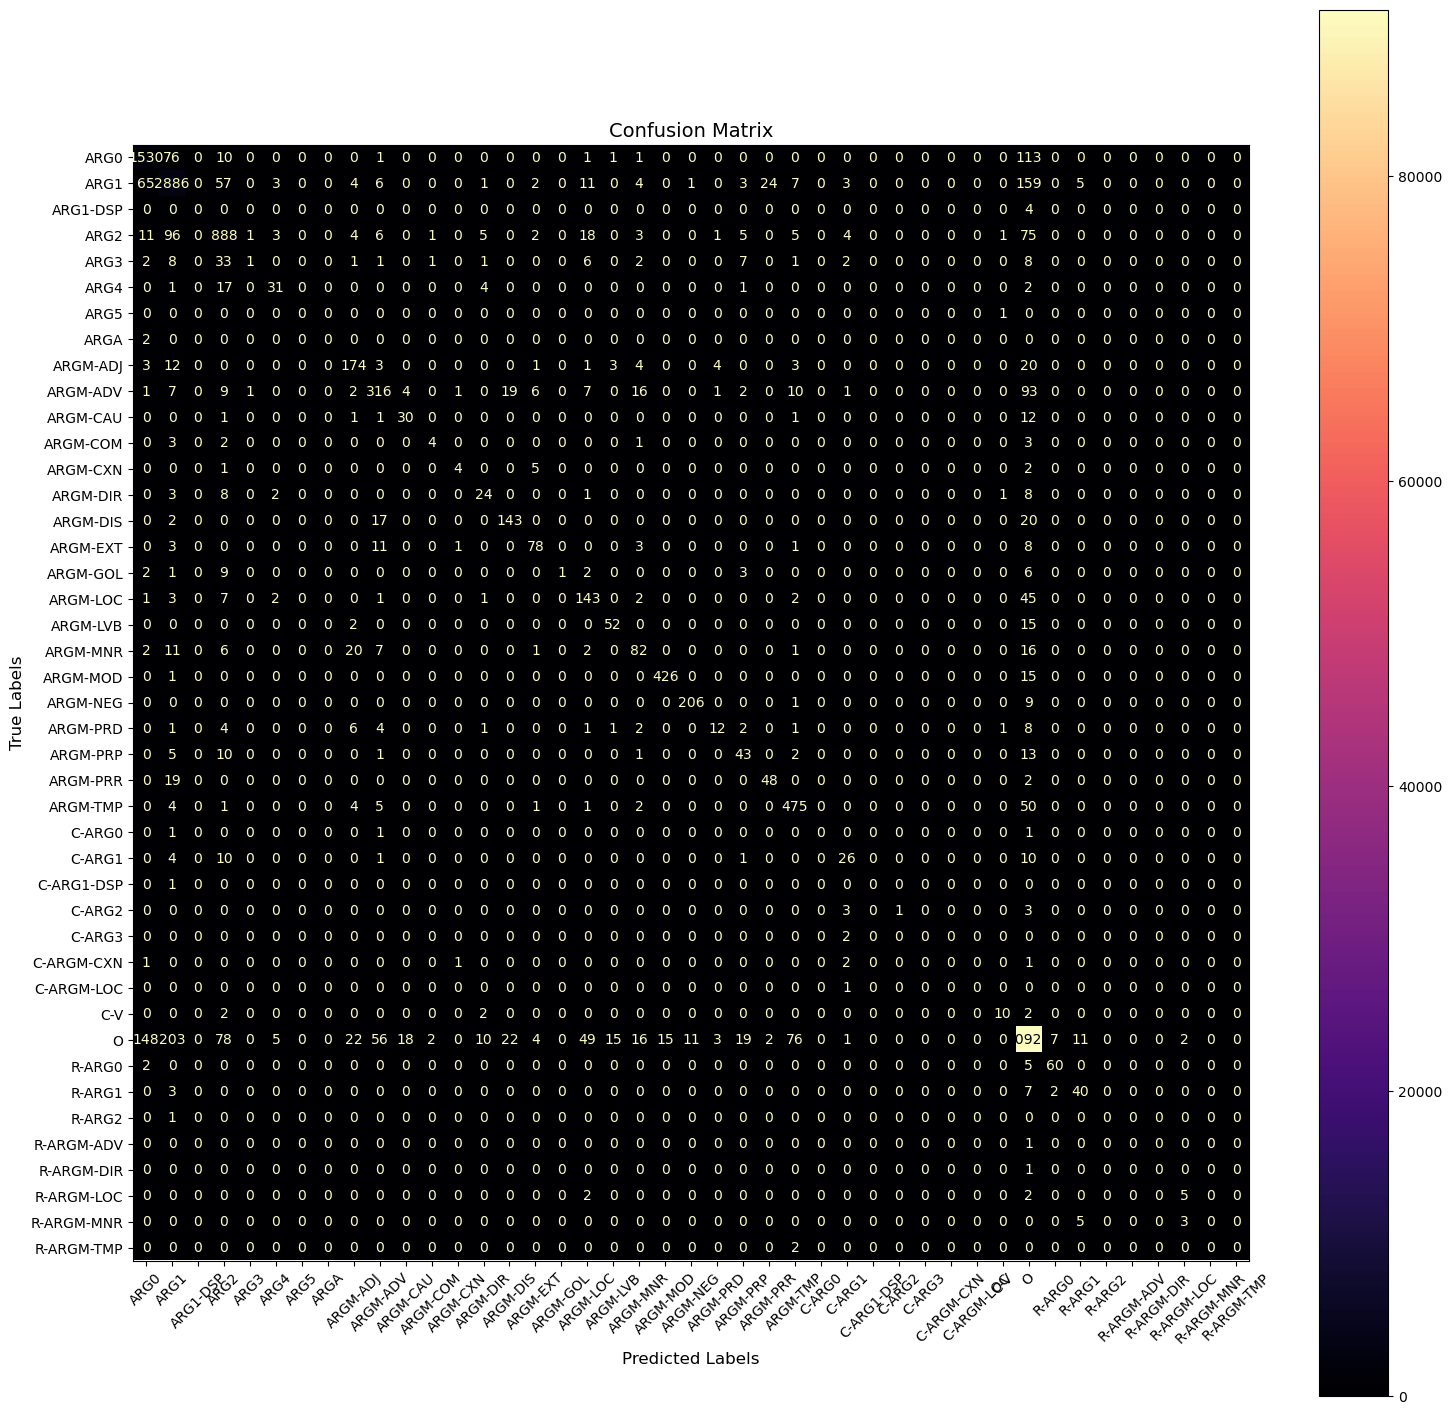

In [198]:
evaluate_file("prediction.tsv", id_to_label)

The classification report indicates that the overall performance of the model is good, but this is largely driven by the overwhelming frequency of the "O" (non-argument) label, similarly to the Logistic Regression classifier. Since "O" accounts for the vast majority of the dataset (over 90% of instances), the model’s high overall performance does not necessarily signify an accurate identification of semantic roles. 

Among the core arguments, ARG0 (often the agent) and ARG1 (often the patient or theme) are identified with relatively high success, with F1-scores of 0.874 and 0.875, respectively. Both have high precision and recall, indicating that they are relatively easier to identify. ARG2, which often corresponds to less frequent roles, performs slightly worse with an F1-score of 0.778, showing that it is harder to detect, though still very well identified.

In contrast, the model struggles with less frequent argument labels, similarly to the Logistic Regression classifier. ARG3, with a precision of 0.333 and recall of 0.014, achieves an F1-score of only 0.026, meaning that this role is almost entirely missed by the model. Similarly, ARG4 and other rare labels also perform poorly, with many of them having an F1-score of 0, which is expected given their close-to-zero representation in the dataset.

The ARGM labels are also more challenging to classify, but quite a few of them present with good results. ARGM-ADJ (adjectival modifiers), ARGM-ADV (adverbial modifiers), and ARGM-TMP (temporal modifiers) perform relatively well, with F1-scores of 0.744, 0.677, and 0.840, respectively. These roles are somewhat easier to identify, though still difficult in comparison to core arguments. 

Overall, the classification report shows that while the model performs well with core arguments that appear frequently in the dataset, it is not able to detect roles that it has not been trained on enough. Labels with counts lower than 100, which may have only a few occurrences in the entire dataset, have F1-scores of 0, which is expected.

## Saving the model

In [93]:
# model.save_pretrained("BERTModel")

In [94]:
# tokenizer.save_pretrained("Tokenizer")

('Tokenizer\\tokenizer_config.json',
 'Tokenizer\\special_tokens_map.json',
 'Tokenizer\\vocab.txt',
 'Tokenizer\\added_tokens.json',
 'Tokenizer\\tokenizer.json')

In [9]:
# with open("srl_trainer.pkl", "wb") as file:
#     pickle.dump(trainer, file)

## Classifying a single sentence

To classify a single sentence, we take as input a list of tokens and a list of 0 and 1, with 1 being the predicate. To pass this sentence to BERT, a `mega_function` was created that follows all of the steps above, but without including labels.

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
from datasets import Dataset
import pickle
from transformers import AutoModelForTokenClassification, AutoTokenizer

In [2]:
from srl_bert_utils import compute_metrics

with open("srl_trainer.pkl", "rb") as model_file:
    pokemon_trainer = pickle.load(model_file)

In [3]:
# this assumes that the model and tokenizer folders are in the same directory as this notebook
pokemon_model = AutoModelForTokenClassification.from_pretrained("BERTModel")
pokemon_tokenizer = AutoTokenizer.from_pretrained("Tokenizer")

In [4]:
def mega_function(sentence_data, pokemon_tokenizer):
    """
    Takes a dataframe that contains two columns: 'token' and 'chosen_predicate'. It executes all the preprocessing steps for BERT,
    i.e. creating the dictionary which contains the predicate values, the special tokens, the input_ids, attention_mask, 
    word_ids, tokenized_tokens, then it only keeps input_ids and attention_mask and creates the dataset that is used with BERT.

    Parameters:
    sentence_data (dataframe): dataframe created by a single sentence containing the columns 'token' and 'chosen_predicate'
    pokemon_tokenizer: custom tokenizer with added special predicate token

    Returns:
    tokenized_data (dictionary): contains all the necessary information to revert the sentence back into its original form
                                 after the subtokenization
    final_dataset (dataset): dataset created using the datasets library, readable by BERT
    """
    
    x = [
            {
            'tokens': sentence_data['token'].tolist(),
            'predicate': [0 if val == 0 else 1 for val in sentence_data['chosen_predicate']]
            }
        ]
    
    y = []
    for sentence in x:
        
        # extracting necessary lists
        tokens = sentence['tokens']
        predicates = sentence['predicate']
    
        # processing tokens based on the predicate
        processed_tokens = []
        processed_predicates = []
        for idx, (token, predicate) in enumerate(zip(tokens, predicates)):
            if predicate == 1:
                processed_predicates.append(predicates[idx])
                processed_tokens.append("[PRED]")

            processed_tokens.append(token)
            processed_predicates.append(predicates[idx])
    
        y.append({
            'tokens':processed_tokens,
            'predicates': processed_predicates
        })

    tokenized_data=[]
    
    for sent in y:
        single_sent={}
        tokenized_input = pokemon_tokenizer(sent["tokens"], is_split_into_words=True)
        tokens = pokemon_tokenizer.convert_ids_to_tokens(tokenized_input["input_ids"])
        word_ids = tokenized_input.word_ids()
        
        single_sent["input_ids"] = tokenized_input["input_ids"]
        single_sent["attention_mask"] = tokenized_input["attention_mask"]
        single_sent['word_ids'] = word_ids
        single_sent['tokenized_tokens'] = tokens
        tokenized_data.append(single_sent)

    
    processed_data = []
    for example in tokenized_data:
        processed_data.append({
            "input_ids": tokenized_data[0]["input_ids"],
            "attention_mask": tokenized_data[0]["attention_mask"],
        })

        
    final_dataset = Dataset.from_dict({
        'input_ids': [example['input_ids'] for example in processed_data],
        'attention_mask': [example['attention_mask'] for example in processed_data]
    })

    return tokenized_data, final_dataset

In [5]:
def get_nth_occurrence_index(ilst, num, n):
    """
    Finds the index of the nth occurrence of a specific element in a list.
    
    Parameters:
    ilst (list): list in which the element is searched
    num (int): element to search for in the list
    n (int): occurrence index

    Returns:
    int: The index of the nth occurrence of the element, or -1 if the element doesn't occur n times.
    """
    count = 0
    for i, val in enumerate(ilst):
        if val == num:
            if count == n:
                return i
            count += 1
    return -1

def transform_to_test_sentence(sent, target, pokemon_trainer, pokemon_model, pokemon_tokenizer):
    """
    Takes as input a list of strings (tokens) and a list of targets (strings of 0 and 1) and turns them into a dataframe
    with word and predicate columns (1 shows the predicate). Then, this dataframe is used in the mega_function, which executes 
    all the necessary preprocessing steps to create the final dataset suitable for BERT. 
    Finally, it predicts, then the special tokens are removed, the majority
    vote of the subtokens is kept, and the final list of predictions is created.
    Handles multiple predicates.

    Parameters:
    sent (list of strings): tokens that make up a sentence. 
    target (list of strings): list which contains as many 0 and 1 as the tokens of 'sent'. 1 represents the predicate.
    pokemon_trainer: trainer that uses the model and tokenizer to classify tokens
    pokemon_model: saved BERT model
    pokemon_tokenizer: custom tokenizer with added special predicate token

    Returns:
    A list of dictionaries with the predictions for each predicate.
    """
    if len(sent) != len(target):
        raise ValueError("The length of the sentence and the list to mark predicate must be the same.")

    label_to_id = {'ARG0': 45, 'ARG1': 0, 'ARG1-DSP': 1, 'ARG2': 17, 'ARG3': 20, 'ARG4': 16, 
                   'ARG5': 26, 'ARGA': 3, 'ARGM-ADJ': 9, 'ARGM-ADV': 19, 'ARGM-CAU': 18, 'ARGM-COM': 24, 
                   'ARGM-CXN': 5, 'ARGM-DIR': 21, 'ARGM-DIS': 15, 'ARGM-EXT': 46, 'ARGM-GOL': 8, 
                   'ARGM-LOC': 47, 'ARGM-LVB': 44, 'ARGM-MNR': 4, 'ARGM-MOD': 11, 'ARGM-NEG': 14, 
                   'ARGM-PRD': 10, 'ARGM-PRP': 23, 'ARGM-PRR': 13, 'ARGM-REC': 12, 'ARGM-TMP': 28, 
                   'C-ARG0': 22, 'C-ARG1': 51, 'C-ARG1-DSP': 58, 'C-ARG2': 30, 'C-ARG3': 25, 'C-ARG4': 56, 
                   'C-ARGM-ADV': 48, 'C-ARGM-COM': 35, 'C-ARGM-CXN': 2, 'C-ARGM-DIR': 29, 'C-ARGM-EXT': 52, 
                   'C-ARGM-GOL': 57, 'C-ARGM-LOC': 54, 'C-ARGM-MNR': 40, 'C-ARGM-PRP': 39, 'C-ARGM-PRR': 32, 
                   'C-ARGM-TMP': 31, 'C-V': 49, 'O': 27, 'R-ARG0': 43, 'R-ARG1': 55, 'R-ARG2': 33, 'R-ARG3': 37, 
                   'R-ARG4': 50, 'R-ARGM-ADV': 34, 'R-ARGM-CAU': 36, 'R-ARGM-COM': 53, 'R-ARGM-DIR': 6, 
                   'R-ARGM-GOL': 7, 'R-ARGM-LOC': 42, 'R-ARGM-MNR': 38, 'R-ARGM-TMP': 41}
    id_to_label = {v: k for k, v in label_to_id.items()}

    pred_num = target.count(1)  # number of predicates in the sentence
    all_predictions = []  # stores predictions for each predicate

    # processes each predicate separately
    for i in range(pred_num):
        test_sentence = []  
        
        # sentence for the current predicate
        for idx, (token, label) in enumerate(zip(sent, target)):
            test_sentence.append(
                {"token": token, 
                 "chosen_predicate": 1 if get_nth_occurrence_index(target, 1, i) == idx else 0})

        # converts list of dicts to dataframe
        sentence_data = pd.DataFrame(test_sentence)
        tokenized_data, final = mega_function(sentence_data, pokemon_tokenizer)

        predictions, _, _ = pokemon_trainer.predict(final)
        predictions = np.argmax(predictions, axis=2)
        
        # attach predictions to tokenized data
        for idx, i in enumerate(tokenized_data):
            length = len(i['word_ids'])
            i['predictions'] = predictions[idx][:length]

        processed_predictions = []
        for data in tokenized_data:
            word_ids = data['word_ids']
            predictions = data['predictions']
            
            # filtering out elements where labels are -100
            word_ids = [b for a, b in zip(data['tokenized_tokens'], word_ids) if a not in ['[CLS]','[SEP]','[PAD]','[PRED]','[UNK]','[MASK]']]
            predictions = [b for a, b in zip(data['tokenized_tokens'], predictions) if a not in ['[CLS]','[SEP]','[PAD]','[PRED]','[UNK]','[MASK]']]

            # initializing variables to track the current group
            current_word_id = None
            current_predictions = []
            
            for idx, word_id in enumerate(word_ids):
                if word_id != current_word_id:
                    # calculating majority vote for the previous group at the start of a new word id
                    if current_predictions:
                        predicted_label_id = Counter(current_predictions).most_common(1)[0][0]
                        processed_predictions.append(id_to_label[predicted_label_id])  # index to label

                    # reset for the new word_id
                    current_word_id = word_id
                    current_predictions = [predictions[idx]]
                else:
                    # add to the current group
                    current_predictions.append(predictions[idx])
            
            # handling the last group
            if current_predictions:
                predicted_label_id = Counter(current_predictions).most_common(1)[0][0]
                processed_predictions.append(id_to_label[predicted_label_id])  # index to label

        all_predictions.append({
            "sentence": sent,
            "raw_predictions": predictions,
            "processed_predictions": processed_predictions
        })
    
    return all_predictions

sent = ["I", "am", "reading", "and", "you", "are", "playing", "an", "instrument", "."]
sent_target = [0, 0, 1, 0, 0, 0, 1, 0, 0, 0]
predictions = transform_to_test_sentence(sent, sent_target, pokemon_trainer, pokemon_model, pokemon_tokenizer)

for pred in predictions:
    print(f"Sentence: {pred['sentence']}")
    print(f"Raw Predictions: {pred['raw_predictions']}")
    print(f"Processed Predictions: {pred['processed_predictions']}")
    print("\n" + "-"*40 + "\n")


Sentence: ['I', 'am', 'reading', 'and', 'you', 'are', 'playing', 'an', 'instrument', '.']
Raw Predictions: [45, 27, 27, 27, 27, 27, 27, 27, 27, 27]
Processed Predictions: ['ARG0', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']

----------------------------------------

Sentence: ['I', 'am', 'reading', 'and', 'you', 'are', 'playing', 'an', 'instrument', '.']
Raw Predictions: [27, 27, 27, 27, 45, 27, 27, 27, 0, 27]
Processed Predictions: ['O', 'O', 'O', 'O', 'ARG0', 'O', 'O', 'O', 'ARG1', 'O']

----------------------------------------



## References

Khandelwal, A., & Sawant, S. (2020). NegBERT: A transfer learning approach for negation detection and scope resolution. Proceedings of the 12th Conference on Language Resources and Evaluation (LREC 2020), 5739–5748. European Language Resources Association (ELRA).\
https://creativecommons.org/licenses/by-nc/4.0/

## Acknowledgements

Handling multiple predicates in the standalone function inspired by Nikhil Matthews (Matt).